In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')

ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

def preparer(df, eloigne=None):
    """Colonnes du modèle. La région entre seulement par l'indicateur 0/1 'eloigne'
    (le code postal est retiré : c'est une copie de la région)."""
    X = df[['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
            'distance_domicile_campus_km', 'premiere_generation_universitaire']].copy()
    X = X.join(pd.get_dummies(df['programme_etudes'], prefix='prog', drop_first=True, dtype=int))
    X['eloigne'] = df['region_administrative'].isin(ELOIGNEES).astype(int) if eloigne is None else eloigne
    return X





In [ ]:
# 1) On apprend les décisions du comité AVEC l'indicateur : la pénalité se loge dedans
modele = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
modele.fit(preparer(demandes), demandes['decision_octroi'])

colonnes = preparer(demandes).columns
coefs = modele[-1].coef_[0]                 # poids appris par la régression logistique
ecarts_types = modele[0].scale_             # le StandardScaler a divisé chaque colonne par son écart-type

poids = pd.DataFrame({
    'poids_standardise': coefs,                 # effet d'un écart-type de la colonne
    'poids_par_unite': coefs / ecarts_types,    # effet d'une unité (1 point de cote R, 1 heure, 1 $...)
}, index=colonnes)
print(poids.round(4))

                                   poids_standardise  poids_par_unite
cote_r_equivalent                             4.1039           1.3663
revenu_familial_estime                        0.7491           0.0000
heures_travail_semaine                        0.7499           0.1971
distance_domicile_campus_km                   0.1226           0.0010
premiere_generation_universitaire            -0.0215          -0.0456
prog_Genie                                    0.0286           0.0679
prog_Sante                                    0.0305           0.0796
prog_Sciences                                 0.0174           0.0425
prog_Sciences sociales                        0.0056           0.0138
eloigne                                      -1.0676          -2.1792


In [6]:
# 2) On note les candidats comme si TOUT LE MONDE venait d'un grand centre (eloigne = 0)
scores = modele.predict_proba(preparer(candidats, eloigne=0))[:, 1]

# 3) On accorde la bourse aux 40 % meilleurs scores (enveloppe 36–44 %)
seuil = np.quantile(scores, 1 - 0.40)
decisions = (scores >= seuil).astype(int)

# Vérification
el = candidats['region_administrative'].isin(ELOIGNEES)
print(f"Taux global      : {decisions.mean():.1%}")
print(f"Grands centres   : {decisions[~el].mean():.1%}")
print(f"Régions éloignées: {decisions[el].mean():.1%}")

Taux global      : 40.0%
Grands centres   : 41.1%
Régions éloignées: 38.4%


In [7]:
soumission = pd.DataFrame({'id_candidat': candidats['id_candidat'], 'decision_octroi': decisions})
soumission.to_csv('predictions.csv', index=False)

taux = soumission['decision_octroi'].mean()
assert len(soumission) == 4000 and soumission['decision_octroi'].isin([0, 1]).all()
print(f"predictions.csv écrit : {len(soumission)} lignes, taux {taux:.1%}",
      "- OK" if 0.36 <= taux <= 0.44 else "- HORS BUDGET")

predictions.csv écrit : 4000 lignes, taux 40.0% - OK


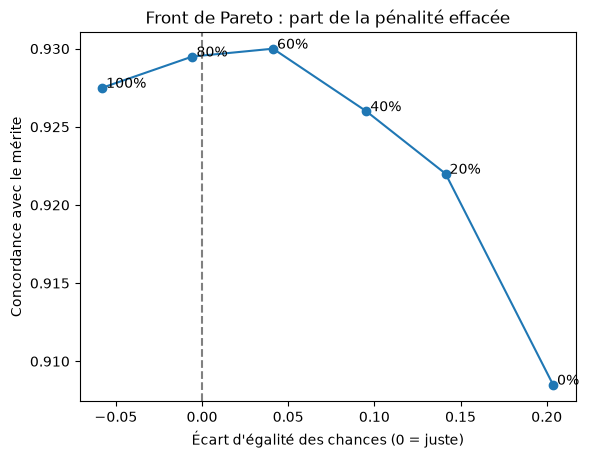

In [8]:
import matplotlib.pyplot as plt

# Référence de mérite : les 40 % meilleures cotes R
cote_r = candidats['cote_r_equivalent']
merite = cote_r >= cote_r.quantile(0.60)

ecarts, concordances, alphas = [], [], [0, 0.2, 0.4, 0.6, 0.8, 1.0]

for alpha in alphas:   # part de la penalite effacer
    scores = modele.predict_proba(preparer(candidats, eloigne=el * (1 - alpha)))[:, 1]
    bourse = scores >= np.quantile(scores, 0.60)
    ecarts.append(bourse[merite & ~el].mean() - bourse[merite & el].mean())
    concordances.append((bourse == merite).mean())

plt.plot(ecarts, concordances, 'o-')
for a, x, y in zip(alphas, ecarts, concordances):
    plt.text(x, y, f' {a:.0%}')
plt.axvline(0, color='grey', ls='--')
plt.xlabel("Écart d'égalité des chances (0 = juste)")
plt.ylabel('Concordance avec le mérite')
plt.title('Front de Pareto : part de la pénalité effacée')
plt.show()